In [133]:
import math
import torch
import matplotlib.pyplot as plt
%matplotlib inline
import torch.nn.functional as F

In [134]:
words =  open('names.txt','r').read().splitlines()

In [135]:
chars = ".abcdefghijklmnopqrstuvwxyz"
stoi = {s: i for i, s in enumerate(chars)}
itos = {i: s for s, i in stoi.items()}

In [136]:
N = torch.zeros((27,27) , dtype=torch.int32)

In [137]:
for w in words:
    chs = ["."]+list(w)+["."]
    for ch1,ch2 in zip(chs,chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1,ix2] += 1

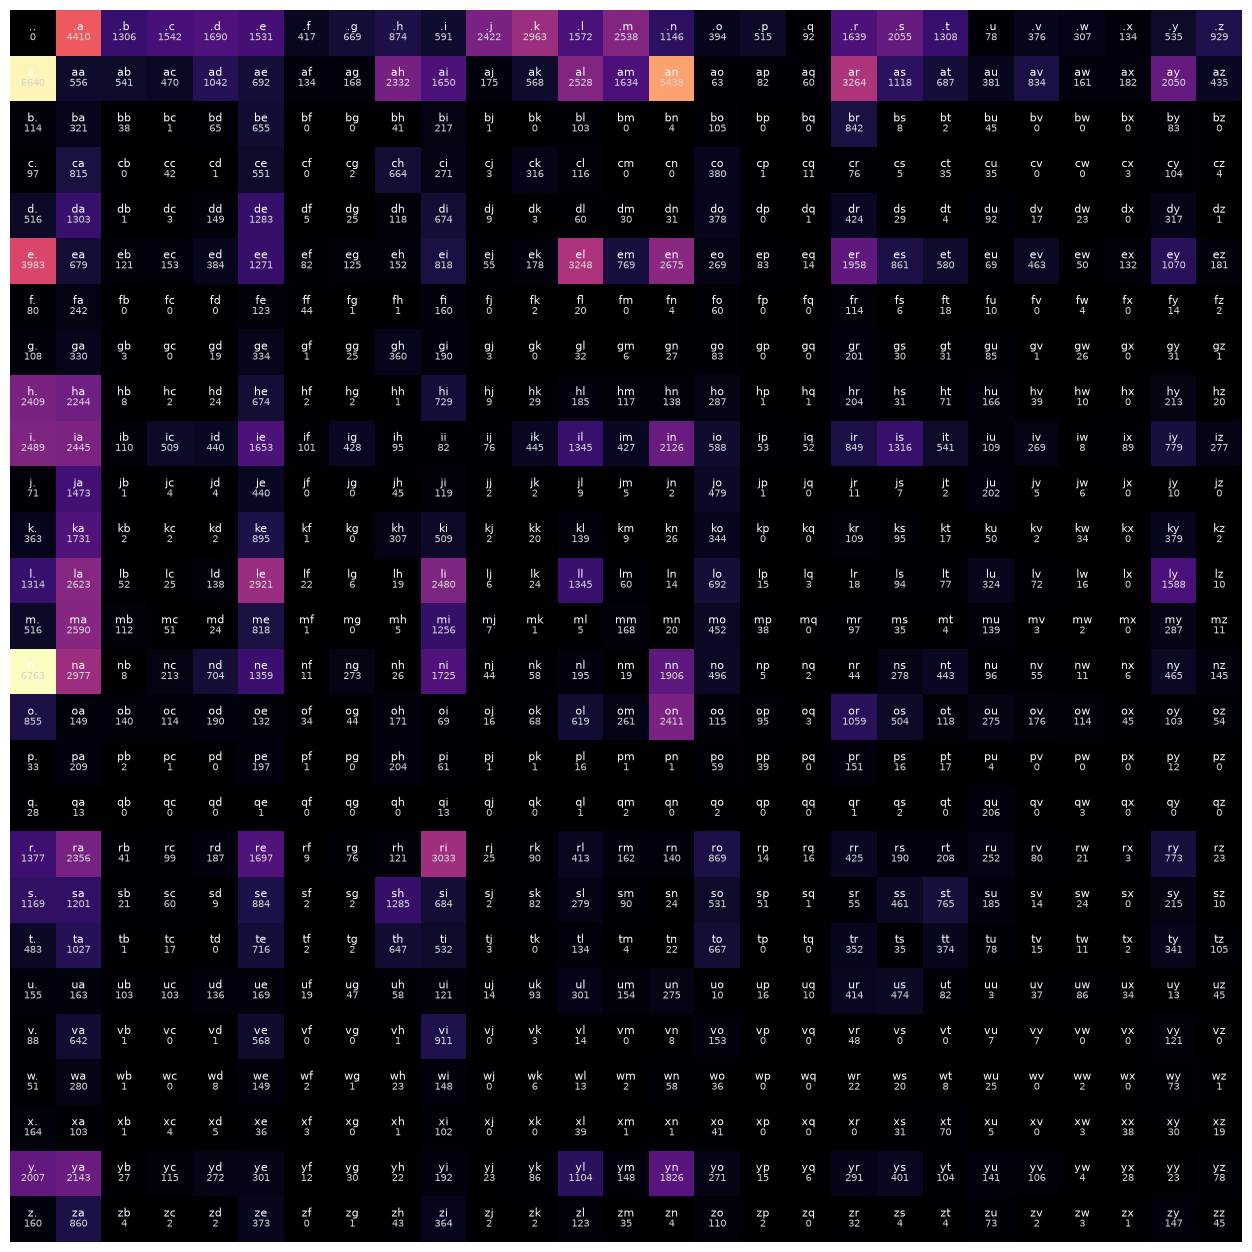

In [138]:

plt.figure(figsize=(16, 16))
plt.imshow(N, cmap="magma")
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color="white", fontsize=8)
        plt.text(j,i,N[i, j].item(),ha="center",va="top",color="lightgray",fontsize=7,)
plt.axis("off")
plt.show()

In [139]:
p = N[0].float()
p = p/p.sum()
p

tensor([0.0000, 0.1377, 0.0408, 0.0481, 0.0528, 0.0478, 0.0130, 0.0209, 0.0273,
        0.0184, 0.0756, 0.0925, 0.0491, 0.0792, 0.0358, 0.0123, 0.0161, 0.0029,
        0.0512, 0.0642, 0.0408, 0.0024, 0.0117, 0.0096, 0.0042, 0.0167, 0.0290])

In [140]:
g = torch.Generator().manual_seed(2147483647)
ix = torch.multinomial(p , num_samples=1 , replacement=True , generator=g).item()
itos[ix]

'c'

In [141]:
g = torch.Generator().manual_seed(2147483647)
p = torch.rand(3,generator=g)
p = p/p.sum()
p

tensor([0.6064, 0.3033, 0.0903])

In [142]:
torch.multinomial(p,num_samples=100,replacement=True,generator=g)

tensor([1, 1, 2, 0, 0, 2, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 2, 0, 0,
        1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1,
        0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
        0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0, 1, 0,
        0, 1, 1, 1])

In [143]:
P = (N+1).float()
P /= P.sum(1,keepdim=True)
"""
here the +1 is due to make everything more distributed , more + means more smoothness
"""

'\nhere the +1 is due to make everything more distributed , more + means more smoothness\n'

In [144]:
"""
what the .sum(x,keepdims) does is that it sum everything accross that dimension and keep dims is saying to keep or not keep that
dimension . For example if we do (1,keepdim=True) then it takes sum across the all of columns of each rows that sum of columns of row
and gives [27*1] with 27 row 1 cols  . if we dont do keepdims as True it is False by defualt and it gives [27]
that just a row vector . it will squeeze out the 1 dimension .
Now what happens when we do P /= P.sum(1,keepdims=True)
P is a 27*27 matrix and P.sum(1,keepdims=True) is a 27*1 maxtrix the rules of these types called broadcasting rules
Shift or push both the martices dimensions to right or start from right
if 27*27 and 27*1   else 27*27 and 27

27 27                   27 27
27 1                       27

Now rule is from either both matrices corresponding dimension should match or either one of them should be one or not present
note that above expamples are both ok and  27*27 and 27*26 is not okay
now what happens is

27 27   in this case we have equal no of rows but only 1 col in second matrix now the broadcasting
27 1    will copy the first value of each row accross all its corresponding cols . think it like streching the first value

27 27 in this case it does the opposite of that if has 27 cols but exactly one row what is does it copy the first value of each col
   27 accross all the rows . LIke the single row is copy pasted 27 times on top of each other
"""

'\nwhat the .sum(x,keepdims) does is that it sum everything accross that dimension and keep dims is saying to keep or not keep that\ndimension . For example if we do (1,keepdim=True) then it takes sum across the all of columns of each rows that sum of columns of row\nand gives [27*1] with 27 row 1 cols  . if we dont do keepdims as True it is False by defualt and it gives [27]\nthat just a row vector . it will squeeze out the 1 dimension .\nNow what happens when we do P /= P.sum(1,keepdims=True)\nP is a 27*27 matrix and P.sum(1,keepdims=True) is a 27*1 maxtrix the rules of these types called broadcasting rules\nShift or push both the martices dimensions to right or start from right\nif 27*27 and 27*1   else 27*27 and 27\n\n27 27                   27 27\n27 1                       27\n\nNow rule is from either both matrices corresponding dimension should match or either one of them should be one or not present\nnote that above expamples are both ok and  27*27 and 27*26 is not okay\nnow w

In [145]:
g = torch.Generator().manual_seed(2147483647)

for i in range(5):
    out = []
    ix = 0
    while True:
        p = P[ix]
        ix = torch.multinomial(p,num_samples=1,replacement=True,generator=g).item()
        out.append(itos[ix])
        if ix==0:
            break
    print(''.join(out))

cexze.
momasurailezitynn.
konimittain.
llayn.
ka.


In [146]:

# GOAL: maximize likelihood of the data w.r.t. model parameters (statistical modeling)
# equivalent to maximizing the log likelihood (because log is monotonic)
# equivalent to minimizing the negative log likelihood
# equivalent to minimizing the average negative log likelihood

# log(a*b*c) = log(a) + log(b) + log(c)

In [147]:
log_likelihood = 0.0
n = 0

for w in words:
    chs = ["."]+list(w)+["."]
    for ch1,ch2 in zip(chs,chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        prob = P[ix1,ix2]
        logprob = torch.log(prob)
        log_likelihood += logprob
        n+=1
print(f'{log_likelihood=}')
nll = -log_likelihood
print(f'{nll=}')
print(f'{nll/n}')

log_likelihood=tensor(-559951.5625)
nll=tensor(559951.5625)
2.4543561935424805


In [148]:
xs ,ys = [], []

for w in words[:1]:
    chs = ['.'] + list(w) + ['.']
    for ch1,ch2 in zip(chs,chs[1:]):
        idx1 = stoi[ch1]
        idx2 = stoi[ch2]
        xs.append(idx1)
        ys.append(idx2)
xs = torch.tensor(xs)
ys = torch.tensor(ys)


In [149]:
print(xs)
print(ys)


tensor([ 0,  5, 13, 13,  1])
tensor([ 5, 13, 13,  1,  0])


In [150]:
xenc = F.one_hot(xs,num_classes=27).float()
xenc

tensor([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [151]:
xenc.shape

torch.Size([5, 27])

In [152]:
W = torch.randn((27,27))
xenc @ W

tensor([[-0.4759,  1.1595, -1.7734,  0.2897,  0.5163, -0.4874, -1.2945, -0.6450,
          0.4803,  1.0352,  2.3764,  0.2509,  1.1277, -0.3214,  0.8814, -1.1886,
         -0.5879, -0.2936, -1.1687,  1.6078, -0.2813,  0.9887, -1.1452, -0.9037,
          0.4072, -0.9446, -0.3052],
        [ 0.0480,  0.2915,  0.0177, -1.2825, -0.3898,  0.1965, -0.2673, -0.1559,
          1.7881, -0.8134, -0.1479,  0.9201,  1.0580,  1.1447,  0.6352,  0.8788,
         -0.3431,  0.1925, -0.1560, -0.2456, -1.2811,  0.0082, -1.4343, -0.6425,
          0.8236, -1.6973,  1.4996],
        [ 0.8951,  0.3108,  0.2402,  1.5526, -0.1624,  1.6954,  0.5983, -0.9766,
          0.8778, -0.2556, -0.6807,  0.3456, -0.5093,  2.1388, -0.5120, -1.2707,
          0.2780,  1.3570,  0.7998,  0.3963,  0.2842, -2.8474,  0.1573,  0.4027,
          0.2910,  1.7480,  0.0075],
        [ 0.8951,  0.3108,  0.2402,  1.5526, -0.1624,  1.6954,  0.5983, -0.9766,
          0.8778, -0.2556, -0.6807,  0.3456, -0.5093,  2.1388, -0.5120, -1.2707

In [153]:
logits = xenc @ W
counts = logits.exp()
probs = counts/counts.sum(1,keepdim=True)
probs

tensor([[0.0139, 0.0711, 0.0038, 0.0298, 0.0374, 0.0137, 0.0061, 0.0117, 0.0361,
         0.0628, 0.2402, 0.0287, 0.0689, 0.0162, 0.0539, 0.0068, 0.0124, 0.0166,
         0.0069, 0.1114, 0.0168, 0.0600, 0.0071, 0.0090, 0.0335, 0.0087, 0.0164],
        [0.0263, 0.0336, 0.0255, 0.0070, 0.0170, 0.0305, 0.0192, 0.0215, 0.1500,
         0.0111, 0.0216, 0.0630, 0.0723, 0.0788, 0.0473, 0.0604, 0.0178, 0.0304,
         0.0215, 0.0196, 0.0070, 0.0253, 0.0060, 0.0132, 0.0572, 0.0046, 0.1124],
        [0.0450, 0.0251, 0.0234, 0.0868, 0.0156, 0.1001, 0.0334, 0.0069, 0.0442,
         0.0142, 0.0093, 0.0260, 0.0110, 0.1560, 0.0110, 0.0052, 0.0243, 0.0714,
         0.0409, 0.0273, 0.0244, 0.0011, 0.0215, 0.0275, 0.0246, 0.1055, 0.0185],
        [0.0450, 0.0251, 0.0234, 0.0868, 0.0156, 0.1001, 0.0334, 0.0069, 0.0442,
         0.0142, 0.0093, 0.0260, 0.0110, 0.1560, 0.0110, 0.0052, 0.0243, 0.0714,
         0.0409, 0.0273, 0.0244, 0.0011, 0.0215, 0.0275, 0.0246, 0.1055, 0.0185],
        [0.0511, 0.0173,

In [154]:
# (5,27) * (27,27) = (5,27)

In [155]:
print(probs[0].sum())
print(probs[0].shape)
probs[0]

tensor(1.)
torch.Size([27])


tensor([0.0139, 0.0711, 0.0038, 0.0298, 0.0374, 0.0137, 0.0061, 0.0117, 0.0361,
        0.0628, 0.2402, 0.0287, 0.0689, 0.0162, 0.0539, 0.0068, 0.0124, 0.0166,
        0.0069, 0.1114, 0.0168, 0.0600, 0.0071, 0.0090, 0.0335, 0.0087, 0.0164])

In [156]:

# SUMMARY ------------------------------>>>>
# randomly initialize 27 neurons' weights. each neuron receives 27 inputs
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27,27) , generator=g)
xenc = F.one_hot(xs, num_classes=27).float() # input to the network: one-hot encoding
logits = xenc @ W # predict log-counts
counts = logits.exp() # counts, equivalent to N
probs = counts / counts.sum(1, keepdims=True) # probabilities for next character
# btw: the last 2 lines here are together called a 'softmax'
probs.shape

torch.Size([5, 27])

In [157]:

nlls = torch.zeros(5)
for i in range(5):
  # i-th bigram:
  x = xs[i].item() # input character index
  y = ys[i].item() # label character index
  print('--------')
  print(f'bigram example {i+1}: {itos[x]}{itos[y]} (indexes {x},{y})')
  print('input to the neural net:', x)
  print('output probabilities from the neural net:', probs[i])
  print('label (actual next character):', y)
  p = probs[i, y]
  print('probability assigned by the net to the the correct character:', p.item())
  logp = torch.log(p)
  print('log likelihood:', logp.item())
  nll = -logp
  print('negative log likelihood:', nll.item())
  nlls[i] = nll

print('=========')
print('average negative log likelihood, i.e. loss =', nlls.mean().item())

--------
bigram example 1: .e (indexes 0,5)
input to the neural net: 0
output probabilities from the neural net: tensor([0.0607, 0.0100, 0.0123, 0.0042, 0.0168, 0.0123, 0.0027, 0.0232, 0.0137,
        0.0313, 0.0079, 0.0278, 0.0091, 0.0082, 0.0500, 0.2378, 0.0603, 0.0025,
        0.0249, 0.0055, 0.0339, 0.0109, 0.0029, 0.0198, 0.0118, 0.1537, 0.1459])
label (actual next character): 5
probability assigned by the net to the the correct character: 0.012286250479519367
log likelihood: -4.3992743492126465
negative log likelihood: 4.3992743492126465
--------
bigram example 2: em (indexes 5,13)
input to the neural net: 5
output probabilities from the neural net: tensor([0.0290, 0.0796, 0.0248, 0.0521, 0.1989, 0.0289, 0.0094, 0.0335, 0.0097,
        0.0301, 0.0702, 0.0228, 0.0115, 0.0181, 0.0108, 0.0315, 0.0291, 0.0045,
        0.0916, 0.0215, 0.0486, 0.0300, 0.0501, 0.0027, 0.0118, 0.0022, 0.0472])
label (actual next character): 13
probability assigned by the net to the the correct character:

In [158]:
# --------- !!! OPTIMIZATION !!! yay --------------

In [159]:
xs

tensor([ 0,  5, 13, 13,  1])

In [160]:
ys

tensor([ 5, 13, 13,  1,  0])

In [161]:

# randomly initialize 27 neurons' weights. each neuron receives 27 inputs
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27,27) , generator=g , requires_grad = True)

In [162]:
# forward pass
xenc = F.one_hot(xs,num_classes=27).float()
logits = xenc @ W
counts = logits.exp()
probs = counts / counts.sum(1,keepdim=True)

In [163]:
probs[0,5],probs[1,13],probs[2,13],probs[3,1],probs[4,0]

(tensor(0.0123, grad_fn=<SelectBackward0>),
 tensor(0.0181, grad_fn=<SelectBackward0>),
 tensor(0.0267, grad_fn=<SelectBackward0>),
 tensor(0.0737, grad_fn=<SelectBackward0>),
 tensor(0.0150, grad_fn=<SelectBackward0>))

In [164]:
loss = -probs[torch.arange(5),ys].log().mean()


In [165]:
print(loss.item())

3.7693049907684326


In [166]:


# backward pass
W.grad = None
loss.backward()

In [167]:
W.data-= 0.1 * W.grad

In [168]:

# create the dataset
xs,ys = [],[]
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1,ch2 in zip(chs,chs[1:]):
        idx1 = stoi[ch1]
        idx2 = stoi[ch2]
        xs.append(idx1)
        ys.append(idx2)

xs =  torch.tensor(xs)
ys = torch.tensor(ys)
num = xs.nelement()

In [169]:
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27,27), generator=g ,requires_grad=True)

In [170]:

# gradient descent
for k in range(100):
    # FORWARD PASS
    xenc = F.one_hot(xs,num_classes=27).float()
    logits = xenc @ W
    counts = logits.exp()
    probs = counts / counts.sum(1,keepdim=True)
    loss = -probs[torch.arange(num), ys].log().mean() + 0.01*(W**2).mean()

    print(loss.item())

    # BACKWARD PASS
    W.grad = None
    loss.backward()

    # UPDATE
    W.data -= 50 * W.grad


3.76861834526062
3.3788065910339355
3.161090850830078
3.0271859169006348
2.9344842433929443
2.867231607437134
2.8166542053222656
2.777146339416504
2.7452542781829834
2.7188305854797363
2.696505546569824
2.6773719787597656
2.6608054637908936
2.6463515758514404
2.633665084838867
2.622471570968628
2.6125476360321045
2.6037068367004395
2.595794439315796
2.5886809825897217
2.582256317138672
2.5764293670654297
2.5711236000061035
2.566272735595703
2.5618226528167725
2.5577261447906494
2.5539445877075195
2.550442695617676
2.5471930503845215
2.5441696643829346
2.5413525104522705
2.538722038269043
2.536262035369873
2.5339579582214355
2.531797409057617
2.5297679901123047
2.527860164642334
2.526063919067383
2.5243709087371826
2.522773265838623
2.52126407623291
2.519836664199829
2.5184855461120605
2.517204999923706
2.515990972518921
2.5148372650146484
2.5137410163879395
2.512698173522949
2.511704444885254
2.5107579231262207
2.509855031967163
2.5089924335479736
2.5081682205200195
2.5073797702789307


In [171]:
# finally, sample from the 'neural net' model
g = torch.Generator().manual_seed(2147483647)

for i in range(5):

  out = []
  ix = 0
  while True:

    # ----------
    # BEFORE:
    #p = P[ix]
    # ----------
    # NOW:
    xenc = F.one_hot(torch.tensor([ix]), num_classes=27).float()
    logits = xenc @ W # predict log-counts
    counts = logits.exp() # counts, equivalent to N
    p = counts / counts.sum(1, keepdims=True) # probabilities for next character
    # ----------

    ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
    out.append(itos[ix])
    if ix == 0:
      break
  print(''.join(out))

cexze.
momasurailezityha.
konimittain.
llayn.
ka.


In [ ]:
"""
The reason we are doing this 0.01*(W**2).mean() is the same as we did this P = (N+1).float()
we N+x  where x>1 because we want smoother and even prob Distribution across everyone . THe more the x is
the more the smoother here too same concept more the weights towards 0 more the counts will be towards 1 and
more the counts towards one more the even probability distribution .
So we want Ws to approach 0 , This is called regularization and 0.01 is a number which can be more or less
so we do (W**2).mean() * Regularization factor or strength
increasing x in N+x is same as increasing Regularization Factor
Essentially what we are doing is logits = xenc @ W , we are doing same thing as our old count table
the fisrt one is finding the appropritae row which is now done by bit set in xenc and find the corresponding ix2
which is ys in this case .
"""